<a href="https://colab.research.google.com/github/henriquecrispim/portfolio-risk-correlation-matrix/blob/main/portfolio_risk_correlation_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_972/2370917694.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_completos = yf.download(tickers, start=data_inicio, end=data_fim)
[*********************100%***********************]  5 of 5 completed

Baixando dados históricos do Yahoo Finance...



/tmp/ipykernel_972/2370917694.py:37: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retornos = dados.pct_change().dropna()


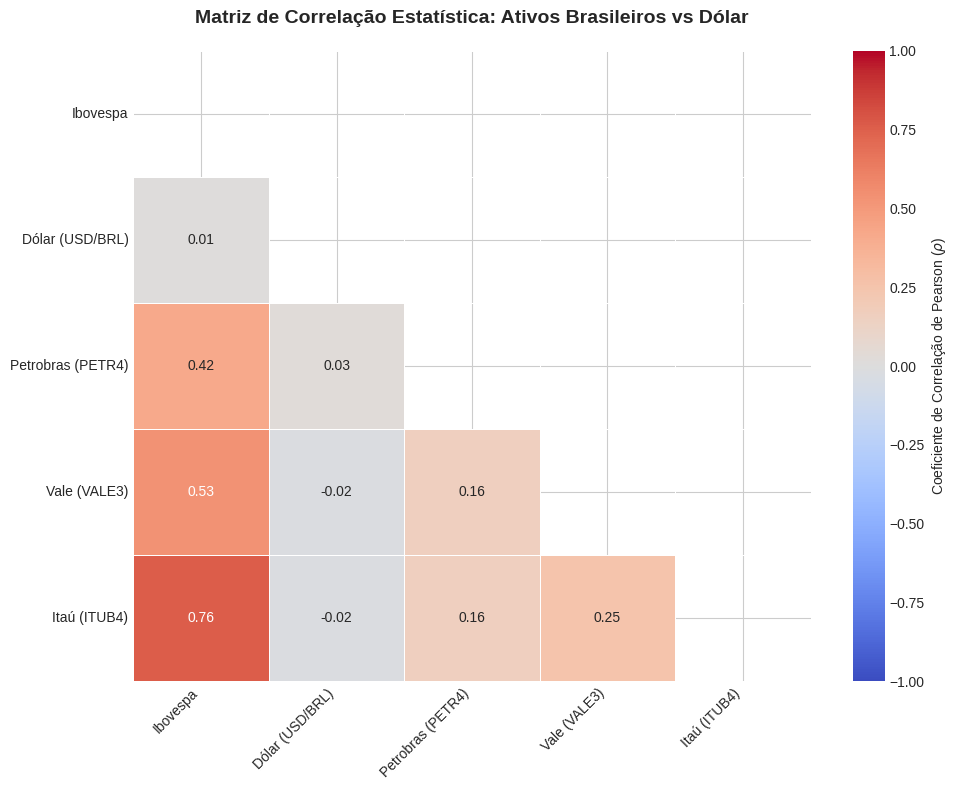


[SUCESSO] Projeto executado por completo!
Gráfico gerado e salvo como 'matriz_correlacao_ativos.png'. pronto para o GitHub.


In [3]:
# ==============================================================================
# PROJETO 2: ANÁLISE DE CORRELAÇÃO E RISCO DE ATIVOS FINANCEIROS (COMPLETO)
# ==============================================================================

# 1. Instalação e Importação das Bibliotecas
!pip install yfinance seaborn matplotlib pandas --quiet

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Definição dos Tickers e Período Histórico
# ^BVSP = Ibovespa | USDBRL=X = Dólar | PETR4.SA = Petrobras | VALE3.SA = Vale | ITUB4.SA = Itaú
tickers = ["^BVSP", "USDBRL=X", "PETR4.SA", "VALE3.SA", "ITUB4.SA"]
data_inicio = "2023-01-01"
data_fim = "2026-06-30"

print("Baixando dados históricos do Yahoo Finance...")
# Captura o DataFrame completo para tratar a estrutura MultiIndex das novas versões do yfinance
dados_completos = yf.download(tickers, start=data_inicio, end=data_fim)

# Tratamento dinâmico de colunas para evitar o erro 'KeyError: Adj Close'
if 'Adj Close' in dados_completos.columns.levels[0]:
    dados = dados_completos['Adj Close']
else:
    dados = dados_completos['Close']

# Sincroniza a ordem exata dos tickers escolhidos
dados = dados[tickers]

# Renomeia as colunas para que o gráfico final fique limpo e legível
dados.columns = ['Ibovespa', 'Dólar (USD/BRL)', 'Petrobras (PETR4)', 'Vale (VALE3)', 'Itaú (ITUB4)']

# 3. Cálculo dos Retornos Diários Percentuais (Garante a estacionaridade estatística)
retornos = dados.pct_change().dropna()

# 4. Cálculo da Matriz de Correlação de Pearson
matriz_correlacao = retornos.corr()

# 5. Visualização Avançada com Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Máscara lógica para ocultar o triângulo superior espelhado do gráfico
mask = np.triu(np.ones_like(matriz_correlacao, dtype=bool))

# Geração do Heatmap via Seaborn
sns.heatmap(
    matriz_correlacao,
    mask=mask,
    annot=True,             # Insere os valores de correlação em cada bloco
    fmt=".2f",              # Duas casas decimais
    cmap="coolwarm",        # Escala divergente: azul (negativo/hedge) a vermelho (positivo)
    vmin=-1, vmax=1,        # Limites matemáticos do coeficiente de Pearson
    linewidths=0.5,         # Gradeado sutil de separação
    cbar_kws={"label": "Coeficiente de Correlação de Pearson ($\\rho$)"}
)

# Ajustes de layout, títulos e rotação dos eixos
plt.title('Matriz de Correlação Estatística: Ativos Brasileiros vs Dólar', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Salva o arquivo final de imagem em alta definição para o repositório do GitHub
plt.savefig('matriz_correlacao_ativos.png', dpi=300)
plt.show()

print("\n[SUCESSO] Projeto executado por completo!")
print("Gráfico gerado e salvo como 'matriz_correlacao_ativos.png'. pronto para o GitHub.")